# MidiTranslator — irregular midiseq2 → Lilylet, model validation

Loads `configs/midi-translator-irregular-to-lilylet.yaml` and validates `MidiTranslator` /
`MidiTranslatorLoss` against the MIXED `Seq2Seq2` batch. The model is the same decoder-only stack as
`midiTranslator_validation.ipynb`. What changes is the sequence, so this notebook checks the parts the
midiseq2 → midiseq2 notebook cannot:

```
<bos>? midiseq2...  <sep>  %style\n ... \n  lilylet... <eos>
└──── source, context ───┘ └──── context ─────┘└── supervised ──┘
```

- **One unified vocabulary of 838 ids, in three disjoint blocks:** 16 shared controls, 248 Lilylet
  content ids (byte values, remapped) and 574 midiseq2 content ids. The source half must hold only
  midiseq2 content, and the target half only Lilylet content.
- **A second unsupervised region inside the target half.** The Lilylet `%` style comments (period /
  composer / instrumentation) lead the target on every crop, closed by a blank line exactly as in the
  file. That blank line is the whole boundary: there is no `<bos>` between style and body, and a
  Lilylet target carries no `<bos>` at all (the source's `<bos>` tells the head condition). The block
  is context only: `target_mask` starts right after the blank line, so the model is never trained to
  write one. `style_dropout` drops each line independently on the train arm. The val arm keeps all
  of them.
- **The shift geometry moves.** The first supervised token is predicted from the blank line that
  closes the style block, not from `<sep>`. Off by one here means one of two silent failures. Either
  the model is trained to write style comments (leakage into the target), or it skips the first body
  token, which is a hole.

Sections:
1. Load the config, a batch, and a small CPU model
2. Batch geometry: five regions, three vocabulary blocks
   (2a. the target decodes back to the Lilylet measures it came from)
   (2b. style dropout: rate, and independence from the crop)
   (2c. `pos_style`: `flat` ≡ `sep`, and `absolute` is refused)
3. The shift, on a hand-built row with a style block
4. Causality and conditioning: both the source AND the style block reach the target
   (4a. the applied attention mask, recovered by perturbation)
5. Padding invariance
6. Loss, metrics, `stat()` folding; what the Lilylet error class is made of
7. Checkpoint contract
8. Overfit one batch
9. Free-run generation, decoded back to Lilylet text

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as tud

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel
from starry.utils.weightedValue import WeightedValue
from starry.midi.data.seq2seq2 import Seq2Seq2

CONFIG = str(REPO_ROOT / 'configs' / 'midi-translator-irregular-to-lilylet.yaml')
DATA_DIR = os.environ['DATA_DIR']
torch.manual_seed(0)

# Okabe-Ito, consistent with the other notebooks in this directory; green is the style context.
C_SRC, C_TGT, C_STY = '#0072B2', '#D55E00', '#009E73'

## 1. Load the config, a batch, and a small CPU model

`volatile=True` builds the config in memory and touches no run directory. The config declares
`assets: [UnifiedSeq2Vocab]`, and a volatile config still needs that artifact to exist, so it is
published to a throwaway directory. The config then injects the same path into `data.args.vocab_path`
and `model.args.vocab_path`, plus the derived `vocab_size` and `eos_id`. The feeder and the loss
therefore read the same mapping, and the cell below asserts it.

`loadModel(config['model'], postfix='Loss')` is the trainer's own call. With a unified `vocab_path`,
`MidiTranslatorLoss` takes its unified branch: a type map with one class per vocabulary region.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)

print('pairing   :', config['data.args.source_dir'], '(%s)' % config['data.args.source_format'],
      '->', config['data.args.target_dir'], '(%s)' % config['data.args.target_format'])
print('mark_mode :', config['data.args.mark_mode'], '| line_range (MEASURES in mixed mode):',
      config['data.args.line_range'])
print('style_dropout: train', config['data.args.style_dropout'],
      '| val', config['data.args_variant'][1]['style_dropout'])
print('vocab     :', config['data.args.vocab_path'])
assert config['data.args.vocab_path'] == config['model.args.vocab_path'], 'feeder and loss read different vocabs'
print('model     :', config['model.type'], '| vocab_size', config['model.args.vocab_size'],
      '| eos_id', config['model.args.eos_id'])

train_loader, val_loader = loadDataset(config, data_dir=DATA_DIR, device='cpu')
train, val = train_loader.dataset, val_loader.dataset
print('samples   : train', len(train), '| val', len(val))

BS = 3
loader = tud.DataLoader(val, batch_size=BS, collate_fn=val.collateBatch)
batch = next(iter(loader))

small = dict(config['model.args'])
small.update(d_model=128, n_layer=2, n_head=4)
model = loadModel({'type': config['model.type'], 'args': small},
    postfix='Loss', imports=config['imports'])
print('\nloadModel ->', type(model).__name__, '| deducer:', type(model.deducer).__name__)
print('params    : %.2fM (small) | vocab %d' % (
    sum(p.numel() for p in model.parameters()) / 1e6, model.deducer.vocab_size))

/home/camus/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pairing   : midi-seq2-irregular (midiseq2) -> lyl (lilylet)
mark_mode : measure | line_range (MEASURES in mixed mode): [2, 12]
style_dropout: train 0.3 | val 0
vocab     : /tmp/starry-volatile-assets-bxp9b0n4/unifiedSeq2Vocab.json
model     : MidiTranslator | vocab_size 838 | eos_id 2
samples   : train 90 | val 9

loadModel -> MidiTranslatorLoss | deducer: MidiTranslator
params    : 1.13M (small) | vocab 838


## 2. Batch geometry: five regions, three vocabulary blocks

A row is `source | <sep> | style | target body | <pad>`. `skip` is not in the batch, because the
collate folds it into `target_mask`. So it is read back from `describe()` for the same sample, with the
split index mapped to a corpus index (`val.indices[r]`, see section 9), and the invariants are checked
against it:

- `target_mask` starts exactly at `sep + 1 + style`. Nothing in the source, at `<sep>`, or inside the
  style block (its closing blank line included) is ever a label.
- The style block decodes to whole `%...\n` lines plus one blank line, and on the val arm it is all
  three lines.
- No `<bos>` anywhere in a Lilylet target. The head condition shows only on the source half.
- **Block purity.** Every source content id is midiseq2, and every target content id is Lilylet.
  Shared controls (`< 16`) are allowed on both sides.

In [3]:
ids, masks, tmask, sep = (batch['input_ids'], batch['masks'], batch['target_mask'], batch['sep_index'])
posn = batch['position_ids']
tok = val.tokenizer
LYL0, LYLN = tok.lilylet_offset, tok.blocks['lilylet']['size']
MID0, MIDN = tok.midiseq2_offset, tok.blocks['midiseq2']['size']
is_lyl = lambda i: LYL0 <= i < LYL0 + LYLN
is_mid = lambda i: MID0 <= i < MID0 + MIDN
is_ctl = lambda i: i < 16
decode = lambda seq: ''.join(tok.tokens[int(i)] for i in seq)

import re
cases_b = [val.describe(val.indices[r]) for r in range(len(ids))]
style_len = [c['style'] for c in cases_b]
print('shapes:', {k: tuple(v.shape) for k, v in batch.items()})
print('vocab blocks: controls 0..15 | lilylet %d..%d | midiseq2 %d..%d\n'
      % (LYL0, LYL0 + LYLN - 1, MID0, MID0 + MIDN - 1))

for r in range(len(ids)):
    n, s, k = int(masks[r].sum()), int(sep[r]), style_len[r]
    first = int(tmask[r].nonzero()[0])
    print('row %d  %-34s len %4d  source %4d  style %3d  supervised %4d  | tmask from %d  head %s'
          % (r, cases_b[r]['name'], n, s, k, int(tmask[r].sum()), first, cases_b[r]['head']))

checks = [
    ('describe() matches the batch row',
        all(torch.equal(torch.tensor(c['ids']), ids[r, :int(masks[r].sum())]) for r, c in enumerate(cases_b))),
    ('target_mask subset of masks', bool(((tmask == 1) <= (masks == 1)).all())),
    ('supervision starts at sep + 1 + style',
        all(int(tmask[r].nonzero()[0]) == int(sep[r]) + 1 + style_len[r] for r in range(len(ids)))),
    ('nothing supervised up to the end of style',
        all(tmask[r, :int(sep[r]) + 1 + style_len[r]].sum() == 0 for r in range(len(ids)))),
    ('skip == style on a Lilylet target', all(c['skip'] == c['style'] for c in cases_b)),
    ('val keeps every style line (3 per file)',
        all(decode(ids[r, int(sep[r]) + 1:int(sep[r]) + 1 + style_len[r]]).count('%') == 3
            for r in range(len(ids)))),
    ('style block is whole %-lines + one blank line, no [field] line',
        all(re.fullmatch(r'(%[^\n]*\n)+\n', decode(ids[r, int(sep[r]) + 1:int(sep[r]) + 1 + style_len[r]]))
            for r in range(len(ids)))),
    ('no <bos> in the Lilylet target',
        all(int((ids[r, int(sep[r]) + 1:int(masks[r].sum())] == tok.bos_id).sum()) == 0 for r in range(len(ids)))),
    ('source <bos> iff head crop',
        all((int(ids[r, 0]) == tok.bos_id) == c['head'] for r, c in enumerate(cases_b))),
    ('exactly one <sep> per row', all(int((ids[r] == tok.sep_id).sum()) == 1 for r in range(len(ids)))),
    ('source content is midiseq2 only',
        all(all(is_ctl(int(i)) or is_mid(int(i)) for i in ids[r, :int(sep[r])]) for r in range(len(ids)))),
    ('target content is Lilylet only',
        all(all(is_ctl(int(i)) or is_lyl(int(i)) for i in ids[r, int(sep[r]) + 1:int(masks[r].sum())])
            for r in range(len(ids)))),
    ('target ends with <eos>', all(int(ids[r, int(masks[r].sum()) - 1]) == tok.eos_id for r in range(len(ids)))),
    ('no <eos> in the source half', all(int((ids[r, :int(sep[r])] == tok.eos_id).sum()) == 0 for r in range(len(ids)))),
    ('no <eom> anywhere (source_eom off, Lilylet bars are "|")', int((ids == tok.eom_id).sum()) == 0),
    ('no <unknown> anywhere', int((ids == tok.unknown_id).sum()) == 0),
]
print()
for name, ok in checks:
    print(('  OK   ' if ok else '  FAIL ') + name)
assert all(ok for _, ok in checks)

shapes: {'input_ids': (3, 1128), 'masks': (3, 1128), 'target_mask': (3, 1128), 'sep_index': (3,), 'position_ids': (3, 1128)}
vocab blocks: controls 0..15 | lilylet 16..263 | midiseq2 264..837

row 0  0000d32362fe8ce09e3729147f12996f   len  712  source  432  style  37  supervised  242  | tmask from 470  head True
row 1  000167012355a695589c9ea5fd8e9c0b   len 1082  source  670  style  39  supervised  372  | tmask from 710  head False
row 2  00021755cfa290c7a7dd3dece1375c43   len 1128  source  838  style  39  supervised  250  | tmask from 878  head False

  OK   describe() matches the batch row
  OK   target_mask subset of masks
  OK   supervision starts at sep + 1 + style
  OK   nothing supervised up to the end of style
  OK   skip == style on a Lilylet target
  OK   val keeps every style line (3 per file)
  OK   style block is whole %-lines + one blank line, no [field] line
  OK   no <bos> in the Lilylet target
  OK   source <bos> iff head crop
  OK   exactly one <sep> per row
  OK   so

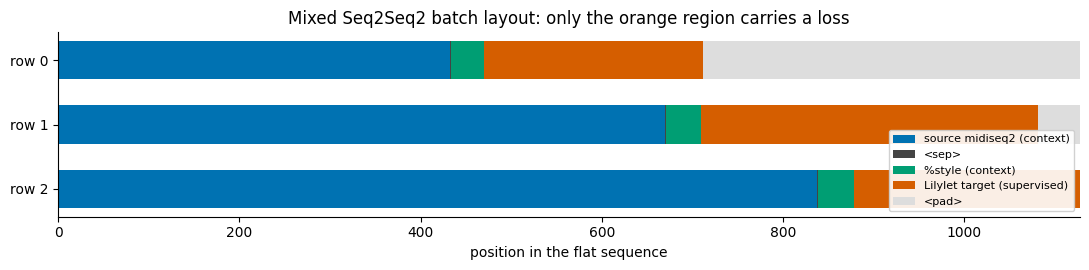

In [4]:
# The five regions of each row, drawn to scale. Only the orange region carries a loss.
fig, ax = plt.subplots(figsize=(11, 1.3 + 0.5 * len(ids)))
for r in range(len(ids)):
    n, s, k = int(masks[r].sum()), int(sep[r]), style_len[r]
    first = r == 0
    ax.barh(r, s, color=C_SRC, height=0.6, label='source midiseq2 (context)' if first else None)
    ax.barh(r, 1, left=s, color='#444444', height=0.6, label='<sep>' if first else None)
    ax.barh(r, k, left=s + 1, color=C_STY, height=0.6, label='%style (context)' if first else None)
    ax.barh(r, n - s - 1 - k, left=s + 1 + k, color=C_TGT, height=0.6,
            label='Lilylet target (supervised)' if first else None)
    ax.barh(r, ids.shape[1] - n, left=n, color='#dddddd', height=0.6, label='<pad>' if first else None)
ax.set_yticks(range(len(ids)))
ax.set_yticklabels([f'row {r}' for r in range(len(ids))])
ax.set_xlabel('position in the flat sequence')
ax.set_title('Mixed Seq2Seq2 batch layout: only the orange region carries a loss')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

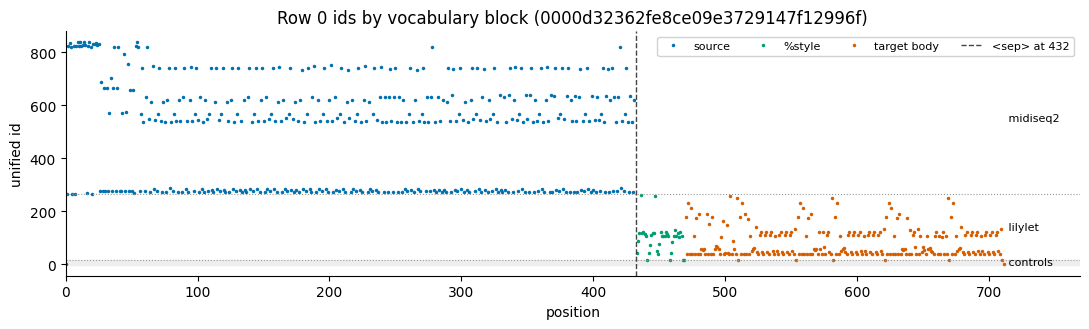

In [5]:
# Block purity, drawn: each id against its position for row 0. The source sits in the midiseq2 band,
# the style and the target in the Lilylet band; controls sit on the floor.
r0 = 0
n0, s0, k0 = int(masks[r0].sum()), int(sep[r0]), style_len[r0]
row0 = ids[r0, :n0].numpy()
x = np.arange(n0)
region = np.where(x < s0, 0, np.where(x == s0, 1, np.where(x <= s0 + k0, 2, 3)))

fig, ax = plt.subplots(figsize=(11, 3.4))
for code_, color, label in ((0, C_SRC, 'source'), (2, C_STY, '%style'), (3, C_TGT, 'target body')):
    sel = region == code_
    ax.plot(x[sel], row0[sel], linestyle='', marker='.', ms=3, color=color, label=label)
ax.axhspan(-0.5, 15.5, color='#eeeeee', zorder=0)
ax.axhline(LYL0 - 0.5, color='#999999', lw=0.8, ls=':')
ax.axhline(MID0 - 0.5, color='#999999', lw=0.8, ls=':')
ax.axvline(s0, color='#444444', lw=1, ls='--', label=f'<sep> at {s0}')
ax.text(n0, 8, ' controls', fontsize=8, va='center')
ax.text(n0, (LYL0 + MID0) / 2, ' lilylet', fontsize=8, va='center')
ax.text(n0, MID0 + MIDN / 2, ' midiseq2', fontsize=8, va='center')
ax.set_xlim(0, n0 * 1.08)
ax.set_xlabel('position'); ax.set_ylabel('unified id')
ax.set_title(f'Row 0 ids by vocabulary block ({cases_b[r0]["name"]})')
ax.legend(fontsize=8, loc='upper right', framealpha=0.9, ncol=4)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### 2a. The target decodes back to its Lilylet measures

The Lilylet tokenizer emits ASCII byte values as LOCAL ids (8..255), and `lilylet_ids` remaps them into
the unified block at 16..263. A remap that is off by the 8 dropped local controls would still pass the
block-purity check above while spelling every character wrong. So the target body is decoded and
compared, character for character, against the concatenated source text of `target_measures`. The
style block is compared against the file's `%` lines plus the closing blank line the same way.

In [6]:
for r, c in enumerate(cases_b):
    style_lines, measures = val._mixed_lilylet_document(c['name'])
    s, k = c['sep'], c['style']
    body_ids = c['ids'][s + 1 + k:-1]
    expect = ''.join(measures[m - 1] for m in c['target_measures'])
    got = decode(body_ids)
    assert got == expect, f'row {r}: decoded target differs from the Lilylet measures'
    assert decode(c['ids'][s + 1:s + 1 + k]) == ''.join(style_lines) + '\n'
    print('row %d  %d measures %s -> %d chars, %d ids (%.2f chars/id) | style %r'
          % (r, len(c['target_measures']), c['target_measures'][:6] + (['...'] if len(c['target_measures']) > 6 else []),
             len(expect), len(body_ids), len(expect) / len(body_ids), ''.join(style_lines).replace('\n', ' ')))
print('\ntarget body and style block decode exactly: True')

print('\nrow 0 target, first 400 chars:\n')
print(decode(cases_b[0]['ids'][cases_b[0]['sep'] + 1:])[:400])

row 0  3 measures [1, 2, 3] -> 385 chars, 241 ids (1.60 chars/id) | style '%Romantic %Chopin, Frederic %Keyboard '
row 1  4 measures [42, 43, 44, 45] -> 588 chars, 371 ids (1.58 chars/id) | style '%Romantic %Gonzaga, Chiquinha %Art Song '
row 2  3 measures [15, 16, 17] -> 363 chars, 249 ids (1.46 chars/id) | style '%Baroque %Corelli, Arcangelo %Chamber '

target body and style block decode exactly: True

row 0 target, first 400 chars:

%Romantic
%Chopin, Frederic
%Keyboard

\staff "1" \key d \major \time 2/4 \clef "treble" \tempo 4=94 ^\markup "Andantino" \p R2 \\
\staff "2" \clef "bass" b,16\sustainOn( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 r4 r8 fs( \\
\staff "2" b,16( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 \grace { fs8 } d'8. d16)( cs b as b \\
\staff "2" b,16\sustainOn( fs' f


### 2b. Style dropout: rate, and independence from the crop

On the train arm each `%` line is dropped independently with probability `style_dropout` (0.3 here).
Every file in this corpus carries exactly three style lines, so the number kept per sample should
follow Binomial(3, 0.7). In particular the whole block is gone with probability 0.3³ = 0.027. That is
the only exposure the model gets to the condition it meets at inference, where it usually has no style
at all.

The draw comes from its own rng stream, so switching dropout on must not move the crop. The check
builds the val arm twice, with dropout 0 and with dropout 0.5, and compares everything except the
style block.

train draws: 1800 (90 files x 20)
lines kept    observed  expected
0               0.0317    0.0270
1               0.2067    0.1890
2               0.4289    0.4410
3               0.3328    0.3430


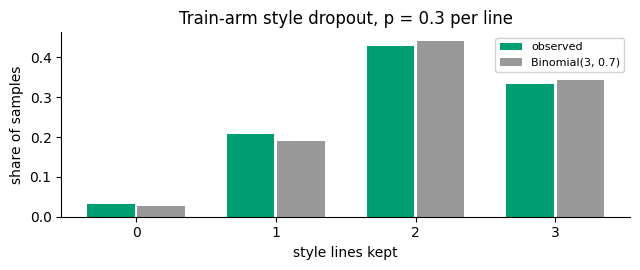


val samples whose crop or body changed when dropout went 0 -> 0.5: 0/9  <- must be 0


In [7]:
from math import comb

p_drop = train.style_dropout
REPS = 20
kept_counts = []
for _ in range(REPS):
    for i in train.indices:
        style_lines, _ = train._mixed_lilylet_document(train.names[i])
        assert len(style_lines) == 3
        kept_counts.append(decode(train._pick_style(i, style_lines)).count('%'))
kept_counts = np.array(kept_counts)
observed = np.bincount(kept_counts, minlength=4) / len(kept_counts)
expected = np.array([comb(3, k) * (1 - p_drop) ** k * p_drop ** (3 - k) for k in range(4)])

print('train draws: %d (%d files x %d)' % (len(kept_counts), len(train.indices), REPS))
print('%-12s %9s %9s' % ('lines kept', 'observed', 'expected'))
for k in range(4):
    print('%-12d %9.4f %9.4f' % (k, observed[k], expected[k]))
assert abs(observed[0] - expected[0]) < 0.02 and abs(observed[3] - expected[3]) < 0.05

fig, ax = plt.subplots(figsize=(6.5, 2.8))
xk = np.arange(4)
ax.bar(xk - 0.18, observed, width=0.34, color=C_STY, label='observed')
ax.bar(xk + 0.18, expected, width=0.34, color='#999999', label='Binomial(3, %.1f)' % (1 - p_drop))
ax.set_xticks(xk); ax.set_xlabel('style lines kept'); ax.set_ylabel('share of samples')
ax.set_title('Train-arm style dropout, p = %.1f per line' % p_drop)
ax.legend(fontsize=8, framealpha=0.9)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

# Independence from the crop: same val sample with dropout 0 and 0.5.
DATA_ROOT = str(Path(DATA_DIR) / config['data.root'])
def val_arm(**over):
    args = dict(config['data.args']); args.update(over)
    return Seq2Seq2.load(DATA_ROOT, args, splits=config['data.splits'],
                         args_variant={1: {**config['data.args_variant'][1], **over}})[1]
full, dropped = val_arm(style_dropout=0.0), val_arm(style_dropout=0.5)
moved = 0
for i in full.indices:
    a, b = full.describe(i), dropped.describe(i)
    same = (a['target_measures'] == b['target_measures'] and a['ids'][:a['sep'] + 1] == b['ids'][:b['sep'] + 1]
            and a['ids'][a['sep'] + 1 + a['style']:] == b['ids'][b['sep'] + 1 + b['style']:])
    moved += not same
print('\nval samples whose crop or body changed when dropout went 0 -> 0.5: %d/%d  <- must be 0'
      % (moved, len(full.indices)))
assert moved == 0

### 2c. `pos_style`: `flat` ≡ `sep`, and `absolute` is refused

In mixed mode only `flat` and `sep` exist. `absolute` places each half on its own file's token axis, and
there is no shared axis between a midiseq2 file and a Lilylet file, so the feeder raises rather than
invent one. `flat` and `sep` differ by a uniform shift, which RoPE cannot see. Their hidden states must
match on an unpadded row.

In [8]:
flat_ds, sep_ds = val_arm(pos_style='flat'), val_arm(pos_style='sep')
_idx = val.indices[0]
cf, cs = flat_ds.describe(_idx), sep_ds.describe(_idx)
assert cf['ids'] == cs['ids'], 'pos_style must not change the ids'
print('flat : source [%d .. %d]  <sep> %d  target [%d .. %d]' % (
    cf['positions'][0], cf['positions'][cf['sep'] - 1], cf['positions'][cf['sep']], cf['positions'][cf['sep'] + 1], cf['positions'][-1]))
print('sep  : source [%d .. %d]  <sep> %d  target [%d .. %d]' % (
    cs['positions'][0], cs['positions'][cs['sep'] - 1], cs['positions'][cs['sep']], cs['positions'][cs['sep'] + 1], cs['positions'][-1]))

model.eval()
with torch.no_grad():
    h = {}
    for name, ds in (('flat', flat_ds), ('sep', sep_ds)):
        _ids, _s, _pos, _skip = ds._item(_idx)
        h[name] = model.deducer.backbone(input_ids=_ids.unsqueeze(0), position_ids=_pos.unsqueeze(0)).last_hidden_state
d = (h['flat'] - h['sep']).abs().max().item()
print('\nflat vs sep max|delta| %.3e  -> equivalent (RoPE is relative)' % d)
assert d < 1e-4

try:
    val_arm(pos_style='absolute')
    raise AssertionError("pos_style='absolute' was accepted in mixed mode")
except ValueError as e:
    print("pos_style='absolute' raises:", e)

flat : source [0 .. 431]  <sep> 432  target [433 .. 711]
sep  : source [-433 .. -2]  <sep> -1  target [0 .. 278]

flat vs sep max|delta| 1.550e-06  -> equivalent (RoPE is relative)
pos_style='absolute' raises: pos_style="absolute" is not defined across mixed token axes


## 3. The shift, on a hand-built row with a style block

The same probe as the midiseq2 notebook, with a style block inserted. The row is

`[m1, m2, <sep>, %, x, \n, \n, l1, l2, <eos>, <pad>]` with `skip = 4` (the style line `%x\n` and
the blank line), so `target_mask` covers positions 7-9. What has to come out:
- labels `[l1, l2, <eos>]`. Neither the style ids nor the blank-line `\n` are labels.
- logits rows `6, 7, 8`. The first body token is predicted from the BLANK LINE (position 6), not from
  `<sep>`. The style block is context that the first supervised prediction is conditioned on.

The ids are real ones taken from the unified vocabulary: `m1`, `m2` from the midiseq2 block, and `%`,
`x`, `\n`, `l1`, `l2` from the Lilylet block.

In [9]:
SEP, EOS, PAD, BOS = tok.sep_id, tok.eos_id, tok.pad_id, tok.bos_id
L = tok.lilylet_id_by_token
M = tok.midiseq2_id_by_token
m1, m2 = M['note_on'], M['#3c']
pct, xch, nl, l1, l2 = L['%'], L['x'], L['\n'], L['c'], L['4']
probe_ids = [m1, m2, SEP, pct, xch, nl, nl, l1, l2, EOS, PAD]
probe = dict(
    input_ids=torch.tensor([probe_ids]),
    masks=torch.tensor([[1] * 10 + [0]]),
    target_mask=torch.tensor([[0] * 7 + [1, 1, 1, 0]]),
)
T = probe['input_ids'].shape[1]
fake = torch.full((1, T, model.deducer.vocab_size), -10.0)
for t in range(T):
    fake[0, t, t * 75] = 10.0          # argmax at position t is t * 75 (< 838 for t <= 10)

pred, labels = model._shift(probe, fake)
used_rows = (pred.argmax(dim=-1) // 75).tolist()
print('labels    :', [tok.tokens[i] for i in labels.tolist()], '  (expect c, 4, <eos>; no style id, no blank line)')
print('logits row:', used_rows, '  (expect [6, 7, 8])')
print('first body token predicted from position 6, the blank line:', used_rows[0] == 6)
print()
print('%-4s %-10s %-16s %s' % ('pos', 'input', 'role', 'predicted from'))
roles = ['source', 'source', '<sep>', 'style ctx', 'style ctx', 'style ctx', 'blank line', 'SUPERVISED',
         'SUPERVISED', 'SUPERVISED', 'padding']
for t in range(T):
    src = ('pos %d' % (t - 1)) if probe['target_mask'][0, t] == 1 else '-'
    print('%-4d %-10r %-16s %s' % (t, tok.tokens[probe_ids[t]], roles[t], src))
assert labels.tolist() == [l1, l2, EOS]
assert used_rows == [6, 7, 8], used_rows
print('\nshift geometry with a style block OK')

labels    : ['c', '4', '<eos>']   (expect c, 4, <eos>; no style id, no blank line)
logits row: [6, 7, 8]   (expect [6, 7, 8])
first body token predicted from position 6, the blank line: True

pos  input      role             predicted from
0    'note_on'  source           -
1    '#3c'      source           -
2    '<sep>'    <sep>            -
3    '%'        style ctx        -
4    'x'        style ctx        -
5    '\n'       style ctx        -
6    '\n'       blank line       -
7    'c'        SUPERVISED       pos 6
8    '4'        SUPERVISED       pos 7
9    '<eos>'    SUPERVISED       pos 8
10   '<pad>'    padding          -

shift geometry with a style block OK


In [10]:
# The same on the REAL batch, verified positionally, plus the two properties that are new here:
# no label ever falls inside a style block, and each row's first label is predicted from the blank
# line that closes it.
with torch.no_grad():
    logits = model.deducer(ids, masks, posn)
pred_r, labels_r = model._shift(batch, logits)

expect_labels, expect_logits, first_from = [], [], []
for r in range(len(ids)):
    s, k = int(sep[r]), style_len[r]
    rows_t = [t for t in range(ids.shape[1]) if tmask[r, t] == 1]
    assert all(t > s + k for t in rows_t), 'a style or source position is supervised'
    first_from.append(rows_t[0] - 1 == s + k and int(ids[r, s + k]) == L['\n'] and int(ids[r, s + k - 1]) == L['\n'])
    for t in rows_t:
        expect_labels.append(int(ids[r, t]))
        expect_logits.append(logits[r, t - 1])

print('supervised positions      :', len(expect_labels), '| _shift returned:', int(labels_r.numel()))
print('labels match position-wise:', labels_r.tolist() == expect_labels)
print('logits match position-wise:', torch.allclose(pred_r, torch.stack(expect_logits)))
print('first label predicted from the closing blank line, every row:', all(first_from))
print('style ids among the labels:', sum(1 for r in range(len(ids)) for t in range(int(sep[r]) + 1, int(sep[r]) + 1 + style_len[r])
                                         if tmask[r, t] == 1), '  <- must be 0')
assert labels_r.tolist() == expect_labels
assert torch.allclose(pred_r, torch.stack(expect_logits))
assert all(first_from)

supervised positions      : 864 | _shift returned: 864
labels match position-wise: True
logits match position-wise: True
first label predicted from the closing blank line, every row: True
style ids among the labels: 0   <- must be 0


## 4. Causality, and two conditioning channels

The midiseq2 notebook checks one conditioning channel, source → target. Here there are two, and both
have to be live:

- **Source → target.** This is the translation itself.
- **Style → target.** The style block is unsupervised, so nothing in the loss requires the model to
  attend to it. The stack must still be *able* to, or `style_dropout` augments a signal that never
  arrives.

Plus the causal property: perturbing position `j` moves nothing before `j`. The perturbations swap a
token for another id from the SAME block, so the probe stays in-distribution.

causality: perturbed target position 591 of 712
  max |delta| before it: 0.000e+00   <- must be 0



perturb source position  216 ('note_off') -> target-body logits move 1.903e-03
perturb style  position  451 ('r'     ) -> target-body logits move 1.314e-03


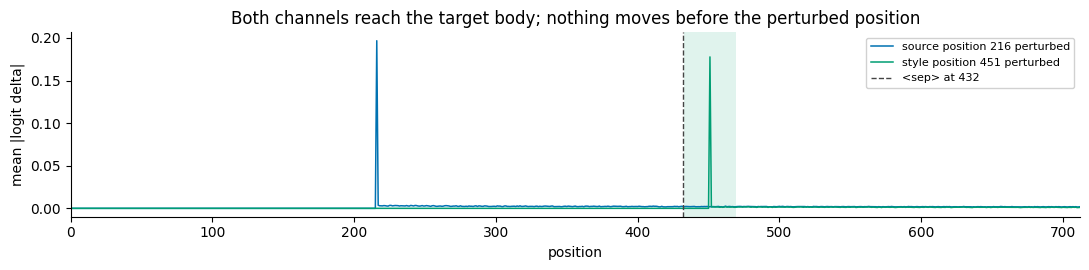

In [11]:
model.eval()
row, row_mask, row_pos = ids[:1].clone(), masks[:1], posn[:1]
n0, s0, k0 = int(row_mask.sum()), int(sep[0]), style_len[0]
body0 = s0 + 1 + k0

def same_block_swap(t, i, off=37):
    i = int(i)
    lo, size = (MID0, MIDN) if is_mid(i) else (LYL0, LYLN) if is_lyl(i) else (0, 16)
    return lo + (i - lo + off) % size

def run(x):
    with torch.no_grad():
        return model.deducer(x, row_mask, row_pos)[0]

base = run(row)

j = (body0 + n0) // 2
bumped = row.clone(); bumped[0, j] = same_block_swap(j, row[0, j])
delta = (run(bumped) - base).abs().mean(dim=-1)
print('causality: perturbed target position %d of %d' % (j, n0))
print('  max |delta| before it: %.3e   <- must be 0' % delta[:j].max())
assert delta[:j].max() == 0 and delta[j:].max() > 0

k = s0 // 2
src_b = row.clone(); src_b[0, k] = same_block_swap(k, row[0, k])
src_shift = (run(src_b) - base).abs()[body0:n0].mean().item()

st = s0 + 1 + k0 // 2
sty_b = row.clone(); sty_b[0, st] = same_block_swap(st, row[0, st])
sty_shift = (run(sty_b) - base).abs()[body0:n0].mean().item()

print('\nperturb source position %4d (%-8r) -> target-body logits move %.3e' % (k, tok.tokens[int(row[0, k])], src_shift))
print('perturb style  position %4d (%-8r) -> target-body logits move %.3e' % (st, tok.tokens[int(row[0, st])], sty_shift))
assert src_shift > 0, 'the target does not depend on the source'
assert sty_shift > 0, 'the target cannot see the style block'

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot((run(src_b) - base).abs().mean(dim=-1).numpy(), color=C_SRC, lw=1.1, label=f'source position {k} perturbed')
ax.plot((run(sty_b) - base).abs().mean(dim=-1).numpy(), color=C_STY, lw=1.1, label=f'style position {st} perturbed')
ax.axvline(s0, color='#444444', ls='--', lw=1, label=f'<sep> at {s0}')
ax.axvspan(s0 + 0.5, body0 - 0.5, color=C_STY, alpha=0.12, lw=0)
ax.set_xlim(0, n0)
ax.set_xlabel('position'); ax.set_ylabel('mean |logit delta|')
ax.set_title('Both channels reach the target body; nothing moves before the perturbed position')
ax.legend(fontsize=8, framealpha=0.9)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### 4a. The visibility matrix, measured rather than drawn

For every key position `j`, perturb it and record which query positions move. The result is the
attention mask the stack actually applies. The row is a short one built from a real sample: 10
source ids, `<sep>`, the first 4 style ids plus the closing `\n\n`, 8 body ids, then 5 pads. The properties to read off it:
- It is lower-triangular over the real region.
- Every body query sees every source key AND every style key.
- The padding columns are dark.

empirical == hand-drawn causal mask: True
future leaks                       : 0   <- must be 0
pad columns reaching a real query  : 0   <- must be 0
body queries see every source key  : True
body queries see every style key   : True


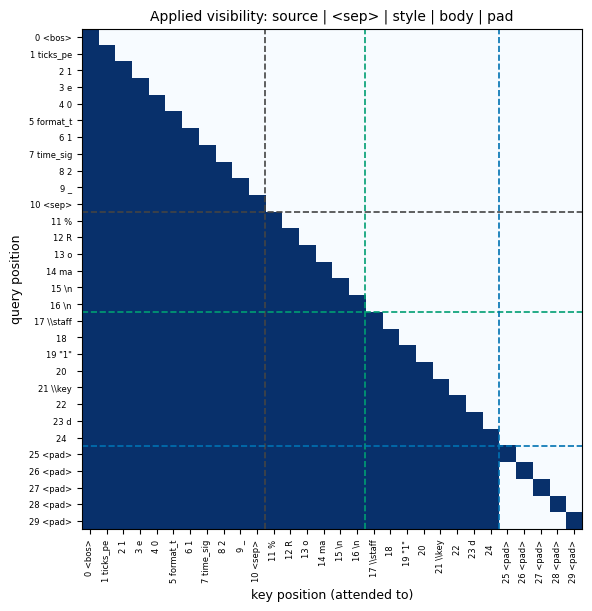

In [12]:
S_SRC, S_STY, S_TGT, S_PAD = 10, 6, 8, 5
_c = cases_b[0]
_full = torch.tensor(_c['ids'], dtype=torch.long)
_s, _k = _c['sep'], _c['style']
demo_ids = torch.cat([
    _full[:S_SRC],
    torch.tensor([tok.sep_id]),
    _full[_s + 1:_s + 1 + S_STY - 2], _full[_s + _k - 1:_s + 1 + _k],
    _full[_s + 1 + _k:_s + 1 + _k + S_TGT],
    torch.full((S_PAD,), tok.pad_id, dtype=torch.long),
]).unsqueeze(0)
T_d = demo_ids.shape[1]
n_real = S_SRC + 1 + S_STY + S_TGT
sep_d, body_d = S_SRC, S_SRC + 1 + S_STY
demo_mask = torch.zeros(1, T_d, dtype=torch.long); demo_mask[0, :n_real] = 1

with torch.no_grad():
    base_d = model.deducer(demo_ids, demo_mask)[0]
vis = np.zeros((T_d, T_d))
for j in range(T_d):
    moved = torch.zeros(T_d)
    for off in (37, 211):
        b_ = demo_ids.clone(); b_[0, j] = (int(demo_ids[0, j]) + off) % model.deducer.vocab_size
        with torch.no_grad():
            moved = torch.maximum(moved, (model.deducer(b_, demo_mask)[0] - base_d).abs().mean(dim=-1))
    vis[:, j] = (moved > 1e-7).numpy()

qi, kj = np.arange(T_d)[:, None], np.arange(T_d)[None, :]
real = demo_mask[0].numpy() == 1
theory = ((kj <= qi) & real[None, :] & real[:, None]).astype(float)
tri_leak = vis[np.triu_indices(n_real, 1)].sum()
pad_leak = vis[:n_real, n_real:].sum()
body_sees_src = vis[body_d:n_real, :sep_d + 1]
body_sees_sty = vis[body_d:n_real, sep_d + 1:body_d]
print('empirical == hand-drawn causal mask:', np.array_equal(vis[:n_real, :n_real], theory[:n_real, :n_real]))
print('future leaks                       :', int(tri_leak), '  <- must be 0')
print('pad columns reaching a real query  :', int(pad_leak), '  <- must be 0')
print('body queries see every source key  :', bool(body_sees_src.all()))
print('body queries see every style key   :', bool(body_sees_sty.all()))
assert tri_leak == 0 and pad_leak == 0 and body_sees_src.all() and body_sees_sty.all()
assert np.array_equal(vis[:n_real, :n_real], theory[:n_real, :n_real])

fig, ax = plt.subplots(figsize=(6.4, 6.0), layout='constrained')
ax.imshow(vis, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
lab = [tok.tokens[int(i)] for i in demo_ids[0]]
lab = ['%d %s' % (i, repr(l)[1:-1][:8]) for i, l in enumerate(lab)]
ax.set_xticks(range(T_d)); ax.set_yticks(range(T_d))
ax.set_xticklabels(lab, rotation=90, fontsize=6); ax.set_yticklabels(lab, fontsize=6)
for v, color in ((sep_d + 0.5, '#444444'), (body_d - 0.5, C_STY), (n_real - 0.5, C_SRC)):
    ax.axvline(v, color=color, lw=1.2, ls='--'); ax.axhline(v, color=color, lw=1.2, ls='--')
ax.set_xlabel('key position (attended to)', fontsize=9); ax.set_ylabel('query position', fontsize=9)
ax.set_title('Applied visibility: source | <sep> | style | body | pad', fontsize=10)
plt.show()

## 5. Padding invariance

Right-padding must not change any row's loss. The batch loss must also be the token-weighted mean of
the per-row losses. In this corpus the rows differ in style length as well as target length, so the
weights are the SUPERVISED counts, which exclude the style block.

In [13]:
def pad_to(b, extra):
    z = lambda t: torch.cat([t, torch.zeros(t.shape[0], extra, dtype=t.dtype)], dim=1)
    grow = torch.stack([p[-1] + torch.arange(1, extra + 1) for p in b['position_ids']])
    return dict(input_ids=z(b['input_ids']), masks=z(b['masks']), target_mask=z(b['target_mask']),
                position_ids=torch.cat([b['position_ids'], grow], dim=1))

model.eval()
with torch.no_grad():
    l_plain, _ = model(batch)
    l_padded, _ = model(pad_to(batch, 64))
    per_row = [model({k: v[r:r + 1, :int(masks[r].sum())] for k, v in batch.items() if k != 'sep_index'})[0].item()
               for r in range(len(ids))]
print('loss, batch           : %.8f' % l_plain.item())
print('loss, + 64 pad columns: %.8f   delta %.2e' % (l_padded.item(), abs(l_plain.item() - l_padded.item())))
assert abs(l_plain.item() - l_padded.item()) < 1e-5

w = tmask.sum(dim=1).float()
weighted = float((torch.tensor(per_row) * w).sum() / w.sum())
print('\nper-row losses (unpadded):', ['%.4f' % x for x in per_row])
print('supervised counts       :', w.long().tolist(), '| style lengths:', style_len)
print('token-weighted mean     : %.8f   (batch loss %.8f)' % (weighted, l_plain.item()))
assert abs(weighted - l_plain.item()) < 1e-4

loss, batch           : 6.77973652
loss, + 64 pad columns: 6.77973652   delta 0.00e+00

per-row losses (unpadded): ['6.7988', '6.7784', '6.7632']
supervised counts       : [242, 372, 250] | style lengths: [37, 39, 39]
token-weighted mean     : 6.77973652   (batch loss 6.77973652)


## 6. Loss, metrics, and what the Lilylet error class is made of

The unified branch of `MidiTranslatorLoss` gives each vocabulary region its own class. The shared
controls are `special`, `<sep>` is `sep`, the midiseq2 block keeps its fine partition (type / elapse /
pitch / ...), and the WHOLE Lilylet block is one class, `lyl`. In this direction the target is Lilylet,
so the eval error panel collapses to one number, `error/lyl`. The midiseq2 classes are absent and
dropped at weight 0. That makes it a coarse diagnostic: a pitch-letter error and a whitespace error
count the same. The composition below shows what `lyl` is averaging over.

In [14]:
model.train()
loss_tr, m_tr = model(batch)
model.eval()
with torch.no_grad():
    loss_ev, m_ev = model(batch)
print('TRAIN keys:', sorted(m_tr.keys()))
print('EVAL  keys:', sorted(m_ev.keys()))
print('\nloss %.4f vs ln(838) = %.4f  (random-init sanity)' % (loss_ev.item(), np.log(model.deducer.vocab_size)))
print('acc weight == supervised count:', m_tr['acc'].weight == int(tmask.sum()))
assert m_tr['acc'].weight == int(tmask.sum())

stat_ev = model.stat(dict(m_ev), 1)
print('\nstat(eval):', stat_ev)
absent = sorted(k[4:] for k, v in m_ev.items() if k.startswith('err_') and v.weight == 0)
print('absent classes (dropped):', absent)
assert set(stat_ev['error']) == {'lyl'}, 'a Lilylet target should report only error/lyl'
assert m_ev['err_lyl'].weight + int((model.type_of_id[labels_r] == 0).sum()) == int(labels_r.numel())

TRAIN keys: ['acc', 'err']
EVAL  keys: ['acc', 'err', 'err_channel', 'err_elapse', 'err_lyl', 'err_nibble', 'err_pitch', 'err_type', 'err_vel']

loss 6.7797 vs ln(838) = 6.7310  (random-init sanity)
acc weight == supervised count: True

stat(eval): {'acc': 0.0, 'err': 1.0, 'error': {'lyl': 1.0}}
absent classes (dropped): ['channel', 'elapse', 'nibble', 'pitch', 'type', 'vel']


supervised tokens: 864

whitespace         305   35.3%
pitch letter       149   17.2%
other symbol       122   14.1%
protected word     118   13.7%
digit               94   10.9%
octave mark         60    6.9%
bar line            13    1.5%
control              3    0.3%


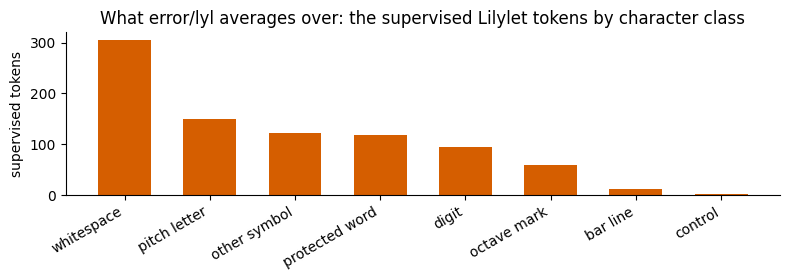

In [15]:
# Composition of the supervised region. <eos> is `special` (a Lilylet target has no <bos>); everything else is one Lilylet
# character or protected multi-character token. Grouped by what the character IS, since the class
# map cannot tell them apart.
import re
lyl_types = {e['token']: e.get('type') for e in val.lilylet_tokenizer.vocab}
def char_class(i):
    t = tok.tokens[i]
    if i < 16: return 'control'
    if lyl_types.get(t) == 'protected' and len(t) > 1: return 'protected word'
    if t in (' ', '\n'): return 'whitespace'
    if re.fullmatch(r'[a-g]', t): return 'pitch letter'
    if t in ("'", ','): return 'octave mark'
    if t.isdigit(): return 'digit'
    if t == '|': return 'bar line'
    if t == '\\': return 'backslash'
    return 'other symbol'

from collections import Counter
comp = Counter(char_class(int(i)) for i in labels_r)
total = sum(comp.values())
print('supervised tokens: %d\n' % total)
for name, c in comp.most_common():
    print('%-15s %6d %6.1f%%' % (name, c, 100 * c / total))

fig, ax = plt.subplots(figsize=(8, 2.9))
names, vals = zip(*comp.most_common())
ax.bar(range(len(names)), vals, color=C_TGT, width=0.62)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('supervised tokens')
ax.set_title('What error/lyl averages over: the supervised Lilylet tokens by character class')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

In [16]:
# loss_type_weights under the unified map: 'lyl' is a valid key here (and only here); an unknown
# name raises; a vocab_size that disagrees with the pinned artifact raises.
import torch.nn.functional as F
assert abs(model._loss(pred_r, labels_r).item() - F.cross_entropy(pred_r, labels_r).item()) < 1e-6
w_lyl = loadModel({'type': config['model.type'], 'args': {**small, 'loss_type_weights': {'lyl': 2.0}}},
                  postfix='Loss', imports=config['imports'])
print("'lyl' weight 2.0 -> weighted_loss:", w_lyl.weighted_loss,
      '| ce weight of a Lilylet id:', float(w_lyl.ce_weight_of_id[LYL0]),
      '| of <eos>:', float(w_lyl.ce_weight_of_id[tok.eos_id]))
for bad, what in (({'loss_type_weights': {'tempo': 2.0}}, 'unknown type name'),
                  ({'vocab_size': 582}, 'vocab_size disagreeing with the artifact')):
    try:
        loadModel({'type': config['model.type'], 'args': {**small, **bad}}, postfix='Loss', imports=config['imports'])
        print('FAIL:', what, 'was accepted')
    except ValueError as e:
        print('%-42s raises: %s' % (what, str(e)[:70]))

'lyl' weight 2.0 -> weighted_loss: True | ce weight of a Lilylet id: 2.0 | of <eos>: 1.0


unknown type name                          raises: unknown loss_type_weights key 'tempo'; valid: ['channel', 'elapse', 'l
vocab_size disagreeing with the artifact   raises: unified vocab_size must be 838, got 582


## 7. Checkpoint contract

The trainer saves only `model.deducer.state_dict()`. The unified type map and CE weights are derived
from the pinned vocab artifact, so they must be non-persistent buffers. The embedding must also have
838 rows, the artifact's size, not the 582 of the midiseq2 asset.

In [17]:
wrapper_only = [n for n, _ in model.named_parameters() if not n.startswith('deducer.')]
saved = model.deducer.state_dict()
emb = [v for k_, v in saved.items() if k_.endswith('embed_tokens.weight')][0]
print('trainable params outside deducer:', wrapper_only, '(must be empty)')
print('embedding rows                  :', emb.shape[0], '(must be %d)' % tok.vocab_size)
print('non-persistent wrapper buffers  :', [n for n in ('type_of_id', 'ce_weight_of_id') if n not in model.state_dict()])
assert not wrapper_only and emb.shape[0] == tok.vocab_size
fresh = loadModel({'type': config['model.type'], 'args': small}, postfix='Loss', imports=config['imports'])
print('state_dict round-trips:', fresh.deducer.load_state_dict(saved, strict=True))

trainable params outside deducer: [] (must be empty)
embedding rows                  : 838 (must be 838)
non-persistent wrapper buffers  : ['type_of_id', 'ce_weight_of_id']
state_dict round-trips: <All keys matched successfully>


## 8. Overfit one batch

This is the end-to-end gradient check. Loss must fall toward 0 and accuracy must approach 1 on one
batch, which says the shift, the style skip and the backprop path agree. Nothing here is about
generalization.

step   0: loss 6.7539  acc 0.000
step 199: loss 0.0227  acc 0.997
acc crosses 0.9 at step 79 | 0.95 at step 87


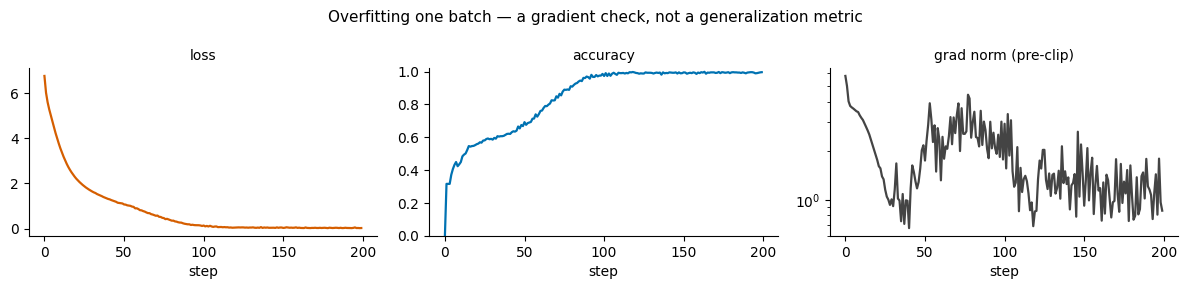

In [18]:
over = loadModel({'type': config['model.type'], 'args': small}, postfix='Loss', imports=config['imports'])
over.train()
opt = torch.optim.Adam(over.parameters(), lr=1.5e-3)
history = []
STEPS = 200
for step in range(STEPS):
    opt.zero_grad()
    loss, metric = over(batch)
    loss.backward()
    gn = torch.nn.utils.clip_grad_norm_([p for p in over.parameters() if p.requires_grad], float('inf'))
    opt.step()
    history.append((loss.item(), metric['acc'].value, float(gn)))

acc_curve = np.array([h[1] for h in history])
cross = lambda th: int(np.argmax(acc_curve >= th)) if (acc_curve >= th).any() else None
print('step   0: loss %.4f  acc %.3f' % history[0][:2])
print('step %3d: loss %.4f  acc %.3f' % ((STEPS - 1,) + history[-1][:2]))
print('acc crosses 0.9 at step', cross(0.9), '| 0.95 at step', cross(0.95))
assert history[-1][0] < history[0][0] * 0.05, 'loss did not fall — the gradient path is broken'
assert history[-1][1] > 0.95, 'accuracy did not reach the batch'

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9))
for ax, idx, label, color in ((axes[0], 0, 'loss', C_TGT), (axes[1], 1, 'accuracy', C_SRC),
                              (axes[2], 2, 'grad norm (pre-clip)', '#444444')):
    ax.plot([h[idx] for h in history], color=color, lw=1.6)
    ax.set_title(label, fontsize=10); ax.set_xlabel('step')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[1].set_ylim(0, 1.02); axes[2].set_yscale('log')
fig.suptitle('Overfitting one batch — a gradient check, not a generalization metric', fontsize=11)
plt.tight_layout(); plt.show()

## 9. Free-run generation, decoded back to Lilylet text

The prefix is what production would hand the model: the source half (with its `<bos>` on a head
crop), `<sep>`, then the style lines the caller knows closed by a blank line, or nothing at all. The
model continues until `<eos>`.

Two things are worth reading here, and neither is about quality, since the model is the batch-overfitted
one from section 8:
- **Termination.** Does it stop at `<eos>`?
- **Block purity of what it emits.** Nothing masks the logits at decode time. A midiseq2 id in the output
  is legal as far as `generate` is concerned, and the only thing preventing one is what the model
  learned. The count is printed.

`describe()` takes a CORPUS index, so row 0 is `val.indices[0]`. The assertion pins it to the
overfitted row. The generation length is bounded by `max_seq_len`; the model does not slide.

In [19]:
case = cases_b[0]
row_ids = torch.tensor(case['ids'], dtype=torch.long)
s, k = case['sep'], case['style']
assert torch.equal(row_ids, ids[0, :int(masks[0].sum())])

prefix_len = s + 1 + k
prefix = row_ids[:prefix_len]
prefix_pos = torch.tensor(case['positions'][:prefix_len], dtype=torch.long)
truth = row_ids[prefix_len:]

over.eval()
gen = over.deducer.generate(prefix, max_new_tokens=min(1200, len(truth) + 60), eos_id=tok.eos_id,
                            temperature=0.0, position_ids=prefix_pos)
off_block = sum(1 for i in gen.tolist() if is_mid(i))
print('sample     :', case['name'], '| head', case['head'], '| measures', case['target_measures'])
print('prefix     : %d ids (source %d + <sep> + style block %d, blank line included)' % (len(prefix), s, k))
print('reference  : %d ids | generated: %d ids' % (len(truth), len(gen)))
print('stopped at <eos>:', bool(len(gen)) and int(gen[-1]) == tok.eos_id)
print('midiseq2 ids emitted into the Lilylet target:', off_block)

n_cmp = min(len(gen), len(truth))
agree = (gen[:n_cmp] == truth[:n_cmp]).numpy()
print('prefix-aligned id match: %d/%d (%.1f%%)' % (agree.sum(), n_cmp, 100 * agree.mean()))

strip = lambda seq: decode([i for i in seq if not is_ctl(int(i))])
print('\nreference (first 300 chars):\n' + strip(truth)[:300])
print('\ngenerated (first 300 chars):\n' + strip(gen)[:300])

sample     : 0000d32362fe8ce09e3729147f12996f | head True | measures [1, 2, 3]
prefix     : 470 ids (source 432 + <sep> + style block 37, blank line included)
reference  : 242 ids | generated: 242 ids
stopped at <eos>: True
midiseq2 ids emitted into the Lilylet target: 0
prefix-aligned id match: 242/242 (100.0%)

reference (first 300 chars):
\staff "1" \key d \major \time 2/4 \clef "treble" \tempo 4=94 ^\markup "Andantino" \p R2 \\
\staff "2" \clef "bass" b,16\sustainOn( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 r4 r8 fs( \\
\staff "2" b,16( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 \grace { f

generated (first 300 chars):
\staff "1" \key d \major \time 2/4 \clef "treble" \tempo 4=94 ^\markup "Andantino" \p R2 \\
\staff "2" \clef "bass" b,16\sustainOn( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 r4 r8 fs( \\
\staff "2" b,16( fs' fs' fs, b, fs' fs' fs, |
\staff "1" \key d \major \time 2/4 \grace { f


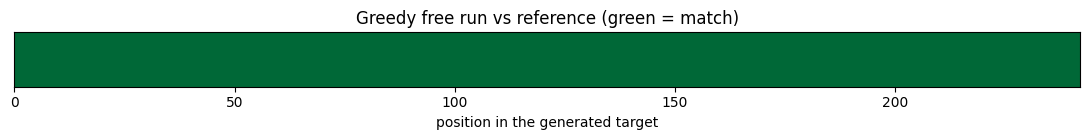

first divergence at none


In [20]:
first_bad = int(np.argmin(agree)) if not agree.all() else n_cmp
fig, ax = plt.subplots(figsize=(11, 1.5))
ax.imshow(agree.reshape(1, -1), aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, extent=[0, n_cmp, 0, 1])
if first_bad < n_cmp:
    ax.axvline(first_bad, color='#000000', lw=1.4)
    ax.text(first_bad, 1.15, f'first divergence at {first_bad}', fontsize=8, ha='left')
ax.set_yticks([]); ax.set_xlabel('position in the generated target')
ax.set_title('Greedy free run vs reference (green = match)')
plt.tight_layout(); plt.show()
print('first divergence at', first_bad if first_bad < n_cmp else 'none')

## What this validates, and what it does not

Validated here:
- **Config and vocab wiring.** The config builds its unified vocab asset through a volatile config, and
  the feeder and the loss read the same artifact.
- **Batch layout.** A row has five regions. Supervision starts exactly after the style block's
  closing blank line. The target carries no `<bos>`; the source's marks the head crop. The source
  holds only midiseq2 content and the target only Lilylet content.
- **Decoding.** The target decodes character for character back to its Lilylet measures, and the style
  block back to the file's `%` lines plus one blank line.
- **Style dropout.** It follows Binomial(3, 0.7) and never moves the crop.
- **Positions.** `flat` ≡ `sep`, and `absolute` is refused.
- **Shift geometry.** The first label is predicted from the blank line, and no style id (nor the
  blank line) is ever a label.
- **Causality and conditioning.** Causality holds, and both the source and the style channels reach the
  target body. The recovered visibility matrix matches the hand-drawn one.
- **Loss.** Padding does not move it, and the batch loss is weighted by supervised tokens.
- **Metrics and checkpoint.** The error panel reduces to `error/lyl`, and `'lyl'` is a valid loss weight.
  The checkpoint contract holds with 838 embedding rows.
- **End to end.** One batch overfits, and free-run generation is assembled and decoded end to end.

Not validated, and known open:
- **Translation quality.** This is the 99-sample `test202608` smoke corpus with a 9-sample val split.
- **Production inference.** `tools/midi/translateMidiseq2.py` refuses a unified vocabulary, so this
  notebook's `generate` call is the only decode path. It does not slide past `max_seq_len`.
- **Decode-time block masking.** Nothing masks the logits by block. Section 9 counts off-block ids;
  nothing prevents them.
- **What `error/lyl` measures.** It is one class over characters of very different importance (see §6).
- **What the val arm measures.** It keeps every style line, while inference usually has none, so val
  loss measures the easy condition.